<a href="https://colab.research.google.com/github/rafayhabibullah/Quant-Analysis/blob/master/BTC_Weekly_SIP_with_Advanced_MA_strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded: 427 rows

=== FINAL SUMMARY ===


,total_invested_usd,final_btc,last_price_usd,portfolio_value_usd,avg_buy_price_usd_per_btc,roi_pct,days_invested
BASIC,3626.000000,0.095190,108642.78,10341.716260,38092.199630,185.210046,259.0
MA_50,3136.000000,0.102272,108642.78,11111.137222,30663.266169,254.309223,259.0
EMA_50,3220.000000,0.106198,108642.78,11537.595240,30320.854937,258.310411,259.0
MA_50_RSI<40,3972.000000,0.142055,108642.78,15433.239479,27961.020286,288.550843,259.0
HYBRID_MA,3360.983565,0.121896,108642.78,13243.069030,27572.656849,294.023618,259.0
DRAWDOWN_DCA,5992.000000,0.196437,108642.78,21341.459552,30503.421576,256.165880,259.0




🔍 Strategy Ranking (by roi_pct) : 🏆 Best Strategy: HYBRID_MA (roi_pct = 294.02)
🔍 Strategy Ranking (by final_btc) : 🏆 Best Strategy: DRAWDOWN_DCA (final_btc = 0.196437)
🔍 Strategy Ranking (by portfolio_value_usd) : 🏆 Best Strategy: DRAWDOWN_DCA (portfolio_value_usd = 21341.46)
🔍 Strategy Ranking (by avg_buy_price_usd_per_btc) : 🏆 Best Strategy: HYBRID_MA (avg_buy_price_usd_per_btc = 27572.66)

🏁 Strategy Composite Ranking (0–1 normalized):


,score,roi_pct,final_btc,avg_buy_price_usd_per_btc
DRAWDOWN_DCA,0.805,0.652,1.000,0.721
MA_50_RSI<40,0.758,0.950,0.463,0.963
HYBRID_MA,0.706,1.000,0.264,1.000
EMA_50,0.460,0.672,0.109,0.739
MA_50,0.423,0.635,0.070,0.706
BASIC,0.000,0.000,0.000,0.000



🏆 Best Strategy: DRAWDOWN_DCA (score = 0.805)


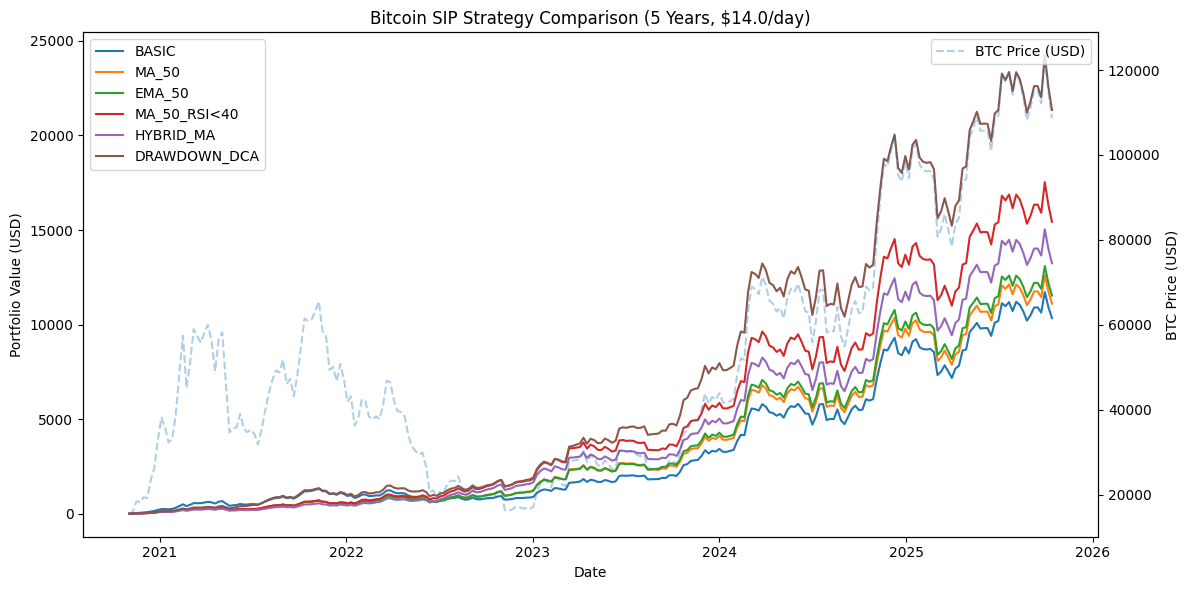

In [85]:
# -------------------------
# BTC SIP Backtest (5 Years, 5 Strategies)
# -------------------------

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
import math
import requests

# -------------------------
# PARAMETERS
# -------------------------
base_daily_usd = 14.0
period_years = 5
end_date = datetime.now(timezone.utc).date()
start_date = end_date - timedelta(days=365 * period_years)
symbol = "BTCUSDT"
interval = "1w"

save_csv = "btc_sip_summary.csv"
save_png = "btc_sip_chart.png"

# -------------------------
# HELPER FUNCTIONS
# -------------------------
def to_float(x):
    """Safely convert scalars or 1-element Series/arrays to float."""
    if isinstance(x, pd.Series):
        if len(x) > 0:
            return float(x.iloc[0])
        else:
            return np.nan
    elif isinstance(x, (np.ndarray, list)):
        if len(x) > 0:
            return float(x[0])
        else:
            return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

def rsi(series, period=14, isSmoothing=False, smoothing=14):
    # 1. Price change
    change = series.diff()

    # 2. Separate gains and losses
    gain = change.clip(lower=0)
    loss = -change.clip(upper=0)

    # 3. Wilder’s smoothing (RMA)
    def rma(series, period):
        return series.ewm(alpha=1/period, adjust=False).mean()

    avg_gain = rma(gain, period)
    avg_loss = rma(loss, period)

    # 4. RSI formula
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# -------------------------
# FETCH DATA
# -------------------------
print(f"Downloading {symbol} data...")

url = f"https://data-api.binance.vision/api/v3/klines?symbol={symbol}&interval={interval}&limit=1000"
response = requests.get(url)
data = response.json()

columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "num_trades",
    "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
]
df_all = pd.DataFrame(data, columns=columns)
df_all.drop(df_all.tail(1).index,inplace = True)

df_all["open_time"] = pd.to_datetime(df_all["open_time"], unit="ms")
df_all["close_time"] = pd.to_datetime(df_all["close_time"], unit="ms")

numeric_cols = ["open", "high", "low", "close", "volume"]

df_all[numeric_cols] = df_all[numeric_cols].apply(pd.to_numeric)
df_all = df_all.set_index("open_time")
df_all = df_all.sort_index()

df_all.index = pd.to_datetime(df_all.index).date
df_all = df_all.sort_index()

print(f"Data loaded: {len(df_all)} rows")

# -------------------------
# CALCULATE INDICATORS
# -------------------------
df_all["ma50"] = df_all["close"].rolling(window=50, min_periods=1).mean()
df_all["ema50"] = df_all["close"].ewm(span=50, adjust=False).mean()
df_all["rsi14"] = rsi(df_all["close"], period=14)

df_all["ma20"] = df_all["close"].rolling(window=20, min_periods=1).mean()
df_all["ma200"] = df_all["close"].rolling(window=200, min_periods=1).mean()

df_all["daily_pct"] = df_all["close"].pct_change() * 100

# -------------------------
# BUY STRATEGIES
# -------------------------
def buy_basic(date, row, df_all):
    return base_daily_usd

def buy_ma50(date, row, df_all):
    close = to_float(row["close"])
    ma50 = to_float(row["ma50"])
    return base_daily_usd * (2.0 if close < ma50 else 0.5)

def buy_ema50(date, row, df_all):
    close = to_float(row["close"])
    ema50 = to_float(row["ema50"])
    return base_daily_usd * (2.0 if close < ema50 else 0.5)

def buy_ma50_rsi40(date, row, df_all):
    close = to_float(row["close"])
    ma50 = to_float(row["ma50"])
    rsi = to_float(row["rsi14"])

    if rsi < 40: return 50.0
    else: return base_daily_usd * (2.0 if close < ma50 else 0.5)


def buy_hybrid_ma(date, row, df_all, base_amount=14, k=5, max_mult=4, min_mult=0.4):
    """
    Hybrid MA-based SIP buy strategy using distance factor.

    Parameters
    ----------
    date : datetime or str
        Current date (index or label from df_all)
    row : pd.Series
        The current row of df_all (should include 'Close' and 'MA50')
    df_all : pd.DataFrame
        Full price data (with 'Close' and 'MA50' columns)
    base_amount : float
        The base weekly investment in euros (default = 14)
    k : float
        Sensitivity factor for distance multiplier (higher = more aggressive)
    max_mult : float
        Maximum allowed multiplier for extreme dips (default = 3×)
    min_mult : float
        Minimum multiplier when price is well above MA (default = 0.25×)

    Returns
    -------
    buy_amount : float
        The euro amount to invest on this date
    """

    close = to_float(row["close"])
    ma50 = to_float(row["ma50"])

    # Calculate percentage distance from MA
    distance = (ma50 - close) / ma50  # positive if price below MA

    # Distance-based multiplier
    multiplier = 1 + k * distance

    # Clamp multiplier between min and max
    multiplier = max(min_mult, min(multiplier, max_mult))

    # Final buy amount
    buy_amount = base_daily_usd * multiplier
    # print(f"Price: {close} | Buy amount: {buy_amount}")

    return buy_amount

def buy_drawdown_dca(date, row, df_all):
    """
    Drawdown-based DCA strategy.

    Invests more when BTC is deeply below its all-time high.

    Parameters
    ----------
    date : datetime
        Current date.
    row : pd.Series
        Current price row (must include 'Close').
    df_all : pd.DataFrame
        Full dataframe (for computing past highs).
    base_amount : float
        Base weekly buy amount in EUR.

    Returns
    -------
    buy_amount : float
        EUR amount to invest this week.
    """

    price = row["close"]

    # Calculate all-time high up to this date
    ath = df_all.loc[:date, "high"].max()

    # Avoid division by zero early in the dataset
    if ath == 0 or pd.isna(ath):
        return base_daily_usd

    # Drawdown from ATH (in %)
    drawdown = (ath - price) / ath

    # Apply tiered multipliers
    if drawdown < 0.10:
        multiplier = 0.5
    elif drawdown < 0.30:
        multiplier = 1
    elif drawdown < 0.50:
        multiplier = 2.0
    else:
        multiplier = 3.0

    buy_amount = base_daily_usd * multiplier
    return buy_amount


# -------------------------
# SIMULATOR
# -------------------------
def simulate_strategy(df, buy_rule_fn):
    df2 = df.copy()
    df2["usd_invested"] = 0.0
    df2["btc_bought"] = 0.0

    for d, row in df2.iterrows():
        usd = to_float(buy_rule_fn(d, row, df2))
        price = to_float(row["close"])

        if np.isnan(price) or price <= 0 or usd <= 0:
            df2.at[d, "usd_invested"] = 0.0
            df2.at[d, "btc_bought"] = 0.0
            continue

        btc = usd / price
        df2.at[d, "usd_invested"] = usd
        df2.at[d, "btc_bought"] = btc

    df2["cum_usd"] = df2["usd_invested"].cumsum()
    df2["cum_btc"] = df2["btc_bought"].cumsum()

    last_price = to_float(df2["close"].iloc[-1])
    final_btc = to_float(df2["cum_btc"].iloc[-1])
    total_invested = to_float(df2["cum_usd"].iloc[-1])
    portfolio_value = final_btc * last_price
    avg_buy_price = total_invested / final_btc if final_btc > 0 else np.nan
    roi_pct = (portfolio_value - total_invested) / total_invested * 100 if total_invested > 0 else np.nan

    stats = {
        "total_invested_usd": total_invested,
        "final_btc": final_btc,
        "last_price_usd": last_price,
        "portfolio_value_usd": portfolio_value,
        "avg_buy_price_usd_per_btc": avg_buy_price,
        "roi_pct": roi_pct,
        "days_invested": int((df2["usd_invested"] > 0).sum())
    }
    return df2, stats

# -------------------------
# RUN STRATEGIES
# -------------------------
strategies = {
    "BASIC": buy_basic,
    "MA_50": buy_ma50,
    "EMA_50": buy_ema50,
    "MA_50_RSI<40": buy_ma50_rsi40,
    "HYBRID_MA": buy_hybrid_ma,
    "DRAWDOWN_DCA": buy_drawdown_dca,
}

results = {}
frames = {}

end_date = datetime.now(timezone.utc).date()
start_date = end_date - timedelta(days=365 * period_years)
df = df_all[df_all.index >= start_date]

for name, fn in strategies.items():
    frame, stats = simulate_strategy(df, fn)
    results[name] = stats
    frames[name] = frame

# -------------------------
# SUMMARY
# -------------------------
summary = pd.DataFrame(results).T
summary = summary[[
    "total_invested_usd",
    "final_btc",
    "last_price_usd",
    "portfolio_value_usd",
    "avg_buy_price_usd_per_btc",
    "roi_pct",
    "days_invested"
]]
summary.to_csv(save_csv)
print("\n=== FINAL SUMMARY ===")
display(summary)
print("\n")

goal = "roi_pct"
ranked = summary.sort_values(by=goal, ascending=False)
print(f"🔍 Strategy Ranking (by {goal}) : 🏆 Best Strategy: {ranked.index[0]} ({goal} = {ranked.iloc[0][goal]:.2f})")

goal = "final_btc"
ranked = summary.sort_values(by=goal, ascending=False)
print(f"🔍 Strategy Ranking (by {goal}) : 🏆 Best Strategy: {ranked.index[0]} ({goal} = {ranked.iloc[0][goal]:.6f})")

goal = "portfolio_value_usd"
ranked = summary.sort_values(by=goal, ascending=False)
print(f"🔍 Strategy Ranking (by {goal}) : 🏆 Best Strategy: {ranked.index[0]} ({goal} = {ranked.iloc[0][goal]:.2f})")

goal = "avg_buy_price_usd_per_btc"
ranked = summary.sort_values(by="avg_buy_price_usd_per_btc", ascending=True)
print(f"🔍 Strategy Ranking (by {goal}) : 🏆 Best Strategy: {ranked.index[0]} ({goal} = {ranked.iloc[0][goal]:.2f})")

weights = {"roi_pct": 0.4, "final_btc": 0.4, "avg_buy_price_usd_per_btc": 0.2}

df_norm = summary.copy()
for col in weights.keys():
    if col not in summary.columns:
        continue
    if col == "avg_buy_price_usd_per_btc":
        # Lower = better → invert normalization
        df_norm[col] = 1 - (summary[col] - summary[col].min()) / (summary[col].max() - summary[col].min())
    else:
        df_norm[col] = (summary[col] - summary[col].min()) / (summary[col].max() - summary[col].min())

# Compute weighted score
df_norm["score"] = sum(df_norm[k] * w for k, w in weights.items())

# Rank
ranked = df_norm.sort_values("score", ascending=False)
best_strategy = ranked.index[0]
best_score = ranked.iloc[0]["score"]

print("\n🏁 Strategy Composite Ranking (0–1 normalized):")
display(ranked[["score", "roi_pct", "final_btc", "avg_buy_price_usd_per_btc"]].round(3))
print(f"\n🏆 Best Strategy: {best_strategy} (score = {best_score:.3f})")

# -------------------------
# PLOT RESULTS
# -------------------------
plt.figure(figsize=(12, 6))
for name, frame in frames.items():
    frame = frame.copy()
    frame["port_value"] = frame["cum_btc"].to_numpy().ravel() * frame["close"].to_numpy().ravel()
    plt.plot(frame.index, frame["port_value"], label=name)

ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(df.index, df["close"], "--", alpha=0.35, label="BTC Price (USD)")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (USD)")
ax2.set_ylabel("BTC Price (USD)")
ax.set_title(f"Bitcoin SIP Strategy Comparison ({period_years} Years, ${base_daily_usd}/day)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig(save_png, dpi=150)
plt.show()